# Clasificación visual con una CNN

### Dataset: Intel Image Classification

Para esta actividad se utilizará el dataset **Intel Image Classification**, disponible en Kaggle. Este conjunto de datos contiene imágenes de escenas naturales de aproximadamente **150 × 150 píxeles**, organizadas en seis categorías: `buildings`, `forest`, `glacier`, `mountain`, `sea` y `street`.

Para el desarrollo de la actividad se conservará `seg_test` como conjunto de prueba independiente y únicamente se dividirá `seg_train` en entrenamiento y validación. De esta manera, el conjunto de prueba permanece aislado durante el entrenamiento y la selección del modelo, permitiendo utilizarlo posteriormente para evaluar su capacidad de generalización.

**Dataset:** [Intel Image Classification — Kaggle](https://www.kaggle.com/datasets/puneet6060/intel-image-classification?resource=download)

## Preparación del entorno

In [9]:
import copy
import random
from pathlib import Path
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 99

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", device)
print("Semilla:", SEED)

PyTorch: 2.14.0
Dispositivo: mps
Semilla: 99


## Lectura del dataset

### ¿Qué se comprueba aquí?

`ImageFolder` organiza automáticamente las imágenes a partir de la estructura de carpetas. Cada subcarpeta representa una clase y cada imagen recibe como etiqueta el índice de su clase.

En esta primera exploración se revisan las clases, el mapeo de etiquetas y el número total de imágenes antes de construir el pipeline de entrenamiento.

In [40]:
# Directorios de origen: entrenamiento y prueba independiente.
TRAIN_DIR = "data/intel-image-classification/seg_train"
TEST_DIR = "data/intel-image-classification/seg_test"

# Hiperparámetros y configuración del experimento.
IMG_SIZE = 128
BATCH_SIZE = 32
VAL_FRACTION = 0.15
EPOCHS = 20
LR = 1e-3

In [3]:
dataset_inspect = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=transforms.ToTensor()
)

class_names = dataset_inspect.classes
targets = np.array(dataset_inspect.targets)

print("Clases:", class_names)
print("Mapeo:", dataset_inspect.class_to_idx)
print("Total:", len(dataset_inspect))

Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Mapeo: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Total: 14034


In [4]:
targets = np.array(dataset_inspect.targets)

for idx, class_name in enumerate(dataset_inspect.classes):
    print(class_name, np.sum(targets == idx))

buildings 2191
forest 2271
glacier 2404
mountain 2512
sea 2274
street 2382


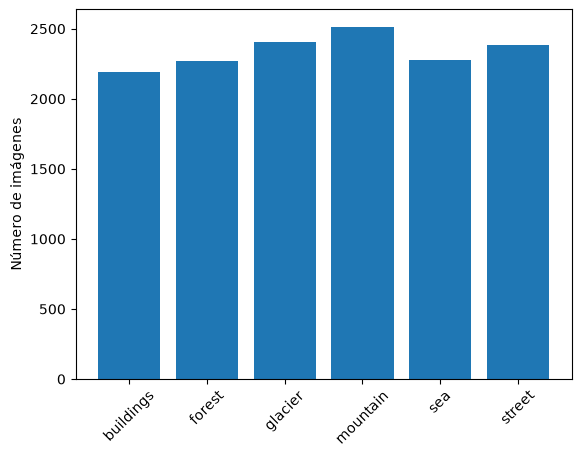

In [5]:
counts = [
    np.sum(targets == idx)
    for idx in range(len(dataset_inspect.classes))
]

plt.bar(dataset_inspect.classes, counts)
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.show()

In [6]:
max_count = max(counts)
min_count = min(counts)

imbalance_ratio = max_count / min_count

print("Clase con más imágenes:", max_count)
print("Clase con menos imágenes:", min_count)
print(f"Relación mayor/menor: {imbalance_ratio:.2f}")

Clase con más imágenes: 2512
Clase con menos imágenes: 2191
Relación mayor/menor: 1.15


### Interpretación de la distribución

El conjunto de entrenamiento contiene 14.034 imágenes repartidas entre seis clases. La clase más frecuente tiene 2.512 imágenes y la menos frecuente 2.191; la relación entre ambas es 1,15. Esta diferencia es pequeña, por lo que no parece necesario aplicar ponderación de clases ni sobremuestreo en este experimento. Aun así, conviene revisar métricas por clase y no quedarse únicamente con la accuracy global

## Inspección visual de las clases

### Lectura de la inspección visual

Antes de entrenar, conviene observar al menos una imagen de cada clase. Esta comprobación permite detectar errores en la organización de carpetas y hacerse una idea de la variabilidad visual que tendrá que aprender la red.

Las escenas pueden compartir elementos: por ejemplo, una imagen de montaña también puede contener cielo, vegetación o nieve. Por eso la clasificación no depende de un único píxel, sino de patrones espaciales.

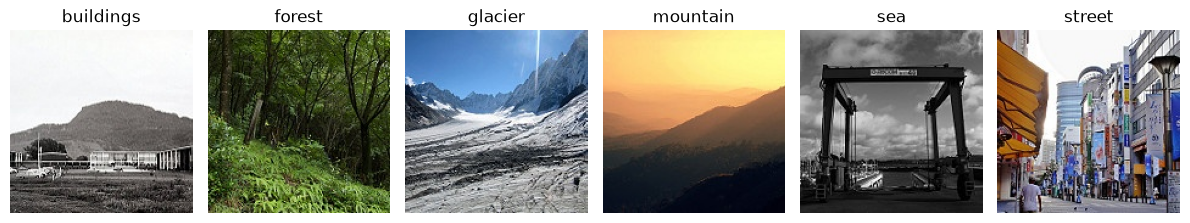

In [7]:
fig, axes = plt.subplots(1, 6, figsize=(12, 7))

for class_idx, ax in enumerate(axes.flat):
    indices = np.where(targets == class_idx)[0]
    idx = indices[0]

    image, label = dataset_inspect[idx]

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(dataset_inspect.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Dimensiones y representación de entrada

### Formato de entrada

Una imagen RGB se representa como un tensor con tres canales: rojo, verde y azul. En PyTorch, el orden habitual es `(canales, alto, ancho)`.

Aunque muchas imágenes del dataset parten de aproximadamente `150 x 150` píxeles, el `Resize` garantiza una dimensión común para formar batches. `ToTensor()` convierte los valores de intensidad al intervalo `[0, 1]`.

In [11]:
sizes = []

for image_path, _ in dataset_inspect.samples:

    with Image.open(image_path) as img:
        sizes.append(img.size)

unique_sizes = sorted(set(sizes))

print(
    "Número de tamaños diferentes:",
    len(unique_sizes)
)

print("\nPrimeros tamaños encontrados:")

for size in unique_sizes[:10]:
    print(size)

Número de tamaños diferentes: 31

Primeros tamaños encontrados:
(150, 76)
(150, 81)
(150, 97)
(150, 100)
(150, 102)
(150, 103)
(150, 105)
(150, 108)
(150, 110)
(150, 111)


In [ ]:
TARGET_SIZE = (150, 150)

same_size = sum(size == TARGET_SIZE for size in sizes)
different_size = len(sizes) - same_size

print("Imágenes 150x150:", same_size)
print("Imágenes con otro tamaño:", different_size)

Imágenes 150x150: 13986
Imágenes con otro tamaño: 48


### Lectura del resultado

La mayoría de las imágenes ya mide 150 x 150 píxeles (13.986 de 14.034) pero existen 48 excepciones, el redimensionamiento garantiza que todas las muestras puedan agruparse en tensores de forma común sin descartar las imágenes atípicas

In [82]:
image, label = dataset_inspect[0]

print("Shape:", image.shape)
print("dtype:", image.dtype)
print("Mínimo:", image.min().item())
print("Máximo:", image.max().item())

Shape: torch.Size([3, 150, 150])
dtype: torch.float32
Mínimo: 0.0
Máximo: 1.0


## Particiones de entrenamiento, validación y prueba

### Principio de la partición

Se divide `seg_train` en entrenamiento y validación mediante índices reproducibles. El conjunto `seg_test` no participa en esta división y queda reservado para la evaluación final.

La validación permite estimar si el modelo generaliza durante el desarrollo, mientras que la prueba debe consultarse una sola vez al final para obtener una medida independiente.

In [ ]:
IMAGE_SIZE = 150

resize_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor()
])

different_idx = None

for idx, (image_path, _) in enumerate(dataset_inspect.samples):

    with Image.open(image_path) as img:
        if img.size != (IMAGE_SIZE, IMAGE_SIZE):
            different_idx = idx
            break

if different_idx is not None:

    original_path, _ = dataset_inspect.samples[different_idx]

    with Image.open(original_path) as img:
        print(
            "Tamaño original:",
            img.size
        )

        resized = resize_transform(img.convert("RGB"))
        print(
            "Tensor después de Resize:",
            resized.shape
        )

Tamaño original: (150, 124)
Tensor después de Resize: torch.Size([3, 150, 150])


In [15]:
num_samples = len(dataset_inspect)

# La semilla hace que la misma partición pueda reproducirse.
generator = torch.Generator().manual_seed(SEED)

# Se barajan índices, no imágenes: el dataset original permanece intacto.
indices = torch.randperm(num_samples, generator=generator).tolist()

train_size = int(0.8 * num_samples)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

print("Train:", len(train_indices))
print("Validation:", len(val_indices))

# Una intersección vacía confirma que no hay muestras compartidas.
print(
    "Elementos compartidos:",
    len(set(train_indices) & set(val_indices))
)

Train: 11227
Validation: 2807
Elementos compartidos: 0


In [ ]:
train_targets = targets[train_indices]
val_targets = targets[val_indices]

for class_idx, class_name in enumerate(class_names):
    train_prop = np.mean(train_targets == class_idx)
    val_prop = np.mean(val_targets == class_idx)

    print(
        f"{class_name:10s} "
        f"train={train_prop:.3f} "
        f"val={val_prop:.3f}"
    )

buildings  train=0.154 val=0.165
forest     train=0.163 val=0.159
glacier    train=0.172 val=0.169
mountain   train=0.177 val=0.186
sea        train=0.162 val=0.162
street     train=0.172 val=0.159


### Lectura de la partición

La división produce 11.227 imágenes para entrenamiento y 2.807 para validación, aproximadamente 80/20
La intersección entre ambos conjuntos es cero y las proporciones por clase son similares

El conjunto proporcionado como seg_test se reservará para la evaluación final.

## Normalización de las imágenes

### ¿Por qué normalizar?

La normalización transforma cada canal usando su media y desviación estándar calculadas sobre el subconjunto de entrenamiento. Así se evita utilizar información del conjunto de prueba para definir el preprocesamiento.

El resultado no tiene por qué quedar entre `0` y `1`: después de normalizar, los valores suelen estar centrados alrededor de cero y expresados en unidades de desviación estándar.

In [ ]:
stats_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor()
])

stats_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=stats_transform)
stats_train_dataset = Subset(stats_dataset, train_indices)

stats_loader = DataLoader(
    stats_train_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)

num_pixels = 0

for images, _ in stats_loader:

    channel_sum += images.sum(dim=[0, 2, 3])
    channel_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    num_pixels += (
        images.size(0)
        * images.size(2)
        * images.size(3)
    )

mean = (channel_sum / num_pixels)
variance = (channel_squared_sum / num_pixels - mean ** 2)

std = torch.sqrt(variance)
MEAN = mean.tolist()
STD = std.tolist()

print("MEAN =", MEAN)
print("STD  =", STD)

MEAN = [0.43040627241134644, 0.4574933350086212, 0.4535215198993683]
STD  = [0.2693118751049042, 0.2678605616092682, 0.2985861897468567]


In [ ]:
original_tensor, _ = stats_dataset[train_indices[0]]

normalize = transforms.Normalize(mean=MEAN, std=STD)
normalized_tensor = normalize(original_tensor.clone())

print("ANTES")

for channel, name in enumerate(["R", "G", "B"]):

    values = original_tensor[channel]

    print(
        name,
        "mean =",
        round(values.mean().item(), 4),
        "std =",
        round(values.std().item(), 4)
    )

print("\nDESPUÉS")

for channel, name in enumerate(["R", "G", "B"]):
    values = normalized_tensor[channel]

    print(
        name,
        "mean =",
        round(values.mean().item(), 4),
        "std =",
        round(values.std().item(), 4)
    )

ANTES
R mean = 0.4605 std = 0.168
G mean = 0.4823 std = 0.1722
B mean = 0.3843 std = 0.171

DESPUÉS
R mean = 0.1119 std = 0.6239
G mean = 0.0926 std = 0.6428
B mean = -0.2318 std = 0.5727


### Lectura de la normalización

Las medias calculadas en entrenamiento son aproximadamente `[0.430, 0.457, 0.454]` y las desviaciones estándar `[0.269, 0.268, 0.299]`

En la muestra ilustrativa, la transformación centra y escala los canales: sus medias pasan a valores cercanos a cero y sus desviaciones quedan alrededor de 0,6

## Pipeline y batches

### Flujo de transformación

Cada imagen pasa por tres pasos: redimensionamiento, conversión a tensor y normalización. El mismo flujo se aplica a entrenamiento, validación y prueba para que el modelo reciba entradas comparables.

Un `DataLoader` agrupa las muestras en batches. En entrenamiento se mezclan los ejemplos para reducir la dependencia del orden; en validación y prueba se conserva un orden estable porque no se actualizan los pesos.

In [19]:
base_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=MEAN,
        std=STD
    )
])

### Creación de los datasets

In [ ]:
train_full_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=base_transform)
val_full_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=base_transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=base_transform)
train_dataset = Subset(train_full_dataset, train_indices)
val_dataset = Subset(val_full_dataset, val_indices)

assert (train_full_dataset.classes == test_dataset.classes)

### Creación de los dataloaders

In [ ]:
BATCH_SIZE = 32

# Fijamos el orden de los batches de entrenamiento para poder reproducir el experimento.
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=train_generator)
# En validación y test no se mezclan las muestras: solo se mide el modelo.
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Comprobación de un batch de imágenes

In [ ]:
images, labels = next(iter(train_loader))

print("Imágenes:", images.shape)
print("Etiquetas:", labels.shape)

Imágenes: torch.Size([32, 3, 150, 150])
Etiquetas: torch.Size([32])


### Comprobación del batch

El batch tiene forma `(32, 3, 150, 150)`: 32 imágenes RGB con altura y anchura de 150 píxeles. Las etiquetas tienen forma `(32,)`, una etiqueta entera por imagen. Esta forma es la que esperan las capas convolucionales y `CrossEntropyLoss`

## Arquitectura de la CNN

### Cómo extrae características la CNN

La red está formada por bloques convolucionales. Las primeras capas detectan bordes, colores y texturas; las capas posteriores combinan esas señales para representar formas y estructuras más complejas.

`MaxPool2d` reduce la resolución espacial y conserva activaciones destacadas. `AdaptiveAvgPool2d` fija el tamaño de la representación antes del clasificador, de modo que la capa lineal reciba siempre el número esperado de valores.

La salida final contiene un valor por clase. Durante el entrenamiento, `CrossEntropyLoss` compara esos valores con la etiqueta correcta y ajusta los filtros mediante retropropagación.

In [ ]:
class SceneCNN(nn.Module):

    def __init__(self, num_classes=6):

        super().__init__()

        # Bloques convolucionales: aumentan canales y reducen resolución espacial.
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Fija el tamaño espacial antes de pasar al clasificador.
        self.pool = nn.AdaptiveAvgPool2d((3, 3))

        # Convierte las características extraídas en puntuaciones por clase.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                128 * 3 * 3,
                128
            ),
            nn.ReLU(),
            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x

In [ ]:
model = SceneCNN(num_classes=len(class_names)).to(device)

print(model)

SceneCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(3, 3))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [43]:
print(
    "Dispositivo:",
    device
)

Dispositivo: mps


In [34]:
sample = images[:4].to(device)

with torch.no_grad():
    output = model(sample)

print(
    "Entrada:",
    sample.shape
)

print(
    "Salida:",
    output.shape
)

Entrada: torch.Size([4, 3, 150, 150])
Salida: torch.Size([4, 6])


### ¿Cuántos valores debe aprender la red?

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(
    f"Parámetros totales: "
    f"{total_params:,}"
)

print(
    f"Parámetros entrenables: "
    f"{trainable_params:,}"
)

Parámetros totales: 241,606
Parámetros entrenables: 241,606


In [36]:
for name, parameter in model.named_parameters():

    print(
        f"{name:35s}",
        f"{parameter.numel():>10,}"
    )

features.0.weight                          864
features.0.bias                             32
features.3.weight                       18,432
features.3.bias                             64
features.6.weight                       73,728
features.6.bias                            128
classifier.1.weight                    147,456
classifier.1.bias                          128
classifier.3.weight                        768
classifier.3.bias                            6


## Entrenamiento de la CNN

In [39]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Definir la función de pérdida

Como tenemos un problema de clasificación multiclase con seis clases, CrossEntropyLoss recibirá directamente los seis logits producidos por la CNN.

In [44]:
criterion = nn.CrossEntropyLoss()

Por eso la arquitectura termina en:

In [45]:
nn.Linear(128, 6)

Linear(in_features=128, out_features=6, bias=True)

### Definir el optimizador

In [ ]:
LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Definir el presupuesto de entrenamiento

In [47]:
EPOCHS = 15

### Configuración antes de entrenar

In [48]:
training_config = {
    "seed": SEED,
    "device": str(device),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "loss": "CrossEntropyLoss",
    "epochs": EPOCHS,
    "train_images": len(train_dataset),
    "validation_images": len(val_dataset),
    "test_images": len(test_dataset),
    "classes": class_names
}

for key, value in training_config.items():
    print(
        f"{key:20s}: {value}"
    )

seed                : 99
device              : mps
image_size          : 150
batch_size          : 32
optimizer           : Adam
learning_rate       : 0.001
loss                : CrossEntropyLoss
epochs              : 15
train_images        : 11227
validation_images   : 2807
test_images         : 3000
classes             : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### Entrenamiento y validación de la CNN


In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        total_loss += (loss.item() * batch_size)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += batch_size

    epoch_loss = (total_loss / total)
    epoch_accuracy = (correct / total)

    return (
        epoch_loss,
        epoch_accuracy
    )

### Función de validación

In [ ]:
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs,labels)
            batch_size = images.size(0)
            total_loss += (loss.item() * batch_size)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += batch_size

    epoch_loss = (total_loss / total)
    epoch_accuracy = (correct / total)

    return (
        epoch_loss,
        epoch_accuracy
    )

### Registro del entrenamiento

In [53]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0

### Ejecución del entrenamiento

In [ ]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/15 | Train Loss: 1.0410 | Val Loss: 0.8834 | Train Acc: 0.5869 | Val Acc: 0.6466
Epoch 02/15 | Train Loss: 0.7008 | Val Loss: 0.5664 | Train Acc: 0.7439 | Val Acc: 0.7919
Epoch 03/15 | Train Loss: 0.5778 | Val Loss: 0.5547 | Train Acc: 0.7877 | Val Acc: 0.7937
Epoch 04/15 | Train Loss: 0.5068 | Val Loss: 0.5155 | Train Acc: 0.8168 | Val Acc: 0.8062
Epoch 05/15 | Train Loss: 0.4624 | Val Loss: 0.4514 | Train Acc: 0.8328 | Val Acc: 0.8432
Epoch 06/15 | Train Loss: 0.4276 | Val Loss: 0.4525 | Train Acc: 0.8448 | Val Acc: 0.8351
Epoch 07/15 | Train Loss: 0.3939 | Val Loss: 0.4465 | Train Acc: 0.8580 | Val Acc: 0.8432
Epoch 08/15 | Train Loss: 0.3667 | Val Loss: 0.4096 | Train Acc: 0.8659 | Val Acc: 0.8561
Epoch 09/15 | Train Loss: 0.3511 | Val Loss: 0.4203 | Train Acc: 0.8741 | Val Acc: 0.8500
Epoch 10/15 | Train Loss: 0.3138 | Val Loss: 0.4263 | Train Acc: 0.8844 | Val Acc: 0.8568
Epoch 11/15 | Train Loss: 0.2935 | Val Loss: 0.4591 | Train Acc: 0.8936 | Val Acc: 0.8425
Epoch 12/1

### Lectura del entrenamiento

La pérdida de entrenamiento desciende de 1,0410 a 0,2154 y la accuracy de entrenamiento alcanza 92,31%
La validación mejora desde 64,66% hasta valores cercanos al 87%, pero oscila a partir de la mitad del entrenamiento
El mejor `validation loss` se obtiene en la época 12

### Recuperar el mejor modelo

Al terminar las 15 épocas, el último modelo no necesariamente es el que mejor generalizó.

Por eso recuperamos el estado con menor validation loss:

In [ ]:
model.load_state_dict(best_model_state)

print(
    "Mejor época:",
    best_epoch
)

print(
    "Mejor validation loss:",
    round(best_val_loss, 4)
)

Mejor época: 12
Mejor validation loss: 0.3841


### Por qué se selecciona la época 12

El criterio de selección es la menor pérdida de validación. En la época 12 se alcanza `validation loss = 0,3841`; después la pérdida de entrenamiento sigue bajando, pero la validación vuelve a empeorar
Esto podría indicar que el modelo está sobreajustado.

## Curvas de aprendizaje e interpretación del entrenamiento

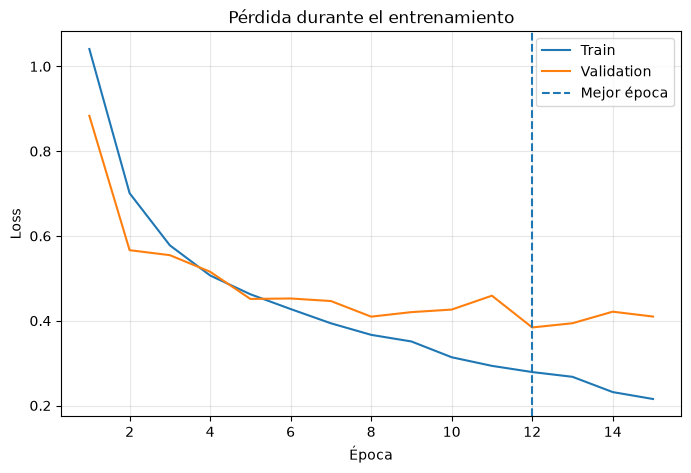

In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train")
plt.plot(epochs_range, history["val_loss"], label="Validation")
plt.axvline(best_epoch, linestyle="--", label="Mejor época")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Pérdida durante el entrenamiento")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Accuracy

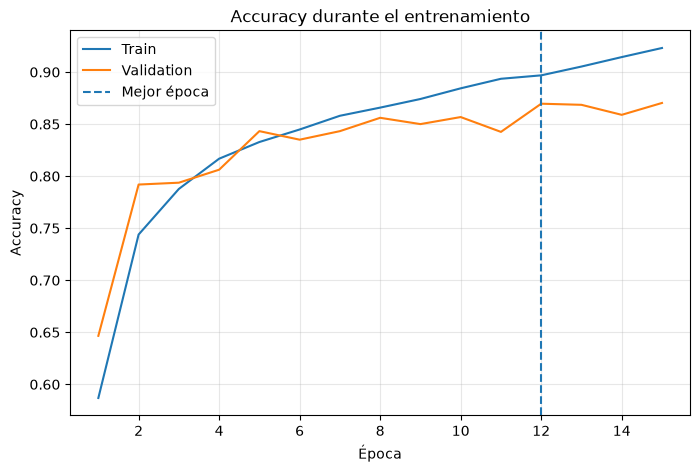

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, history["train_accuracy"], label="Train")
plt.plot(epochs_range, history["val_accuracy"], label="Validation")
plt.axvline(best_epoch, linestyle="--", label="Mejor época")

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Medir la diferencia entre train y validation

In [ ]:
final_train_acc = history["train_accuracy"][-1]
final_val_acc = history["val_accuracy"][-1]
accuracy_gap = (final_train_acc - final_val_acc)

print(
    f"Train accuracy final: "
    f"{final_train_acc:.4f}"
)

print(
    f"Validation accuracy final: "
    f"{final_val_acc:.4f}"
)

print(
    f"Diferencia train - validation: "
    f"{accuracy_gap:.4f}"
)

Train accuracy final: 0.9231
Validation accuracy final: 0.8703
Diferencia train - validation: 0.0528


### Interpretación de la brecha

La brecha final entre entrenamiento y validación es de 0,0528 puntos de accuracy: 92,31% frente a 87,03%
No es una separación grande esto confirma que el modelo aprende algunos patrones específicos del entrenamiento

## Evaluación final del modelo

### Obtener las predicciones de test

In [ ]:
def predict_dataset(
    model,
    loader,
    device
):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            y_true.extend(labels.numpy())
            y_pred.extend(predictions.cpu().numpy())

    return (
        np.array(y_true),
        np.array(y_pred)
    )

In [ ]:
y_true, y_pred = predict_dataset(model, test_loader, device)
print(
    "Imágenes de test:",
    len(y_true)
)

Imágenes de test: 3000


### Accuracy global

In [79]:
test_accuracy = accuracy_score(y_true, y_pred)
print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Accuracy: 86.20%


### Resultado global en test

La accuracy en el conjunto de prueba es 86,20%: 2.586 aciertos de 3.000 imágenes y 414 errores
El resultado es coherente con la validación (87,03%), lo que sugiere que la estimación de generalización no se alejó mucho al evaluar datos no utilizados durante el desarrollo

### Precision, recall y F1 por clase

In [64]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

   buildings     0.8174    0.8604    0.8384       437
      forest     0.9429    0.9747    0.9585       474
     glacier     0.8708    0.7559    0.8093       553
    mountain     0.8004    0.8400    0.8197       525
         sea     0.8787    0.8804    0.8795       510
      street     0.8661    0.8782    0.8722       501

    accuracy                         0.8620      3000
   macro avg     0.8627    0.8649    0.8629      3000
weighted avg     0.8626    0.8620    0.8614      3000



### Lectura de las métricas por clase

El rendimiento no es uniforme. `forest` es la clase mejor reconocida, con F1 = 0,9585 y recall = 0,9747
`glacier` presenta el F1 más bajo, 0,8093, principalmente porque su recall es 0,7559: una parte relevante de los glaciares se asigna a la clase `mountain`
La media macro de F1 es 0,8629, muy próxima a la accuracy global, coherente con un dataset razonablemente equilibrado

### Identificar diferencias entre clases

In [ ]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

f1_by_class = {class_name: report_dict[class_name]["f1-score"] for class_name in class_names}
best_f1_class = max(f1_by_class, key=f1_by_class.get)
worst_f1_class = min(f1_by_class, key=f1_by_class.get)

print(
    "Clase con mayor F1:",
    best_f1_class,
    f"{f1_by_class[best_f1_class]:.4f}"
)

print(
    "Clase con menor F1:",
    worst_f1_class,
    f"{f1_by_class[worst_f1_class]:.4f}"
)

Clase con mayor F1: forest 0.9585
Clase con menor F1: glacier 0.8093


### Matriz de confusión

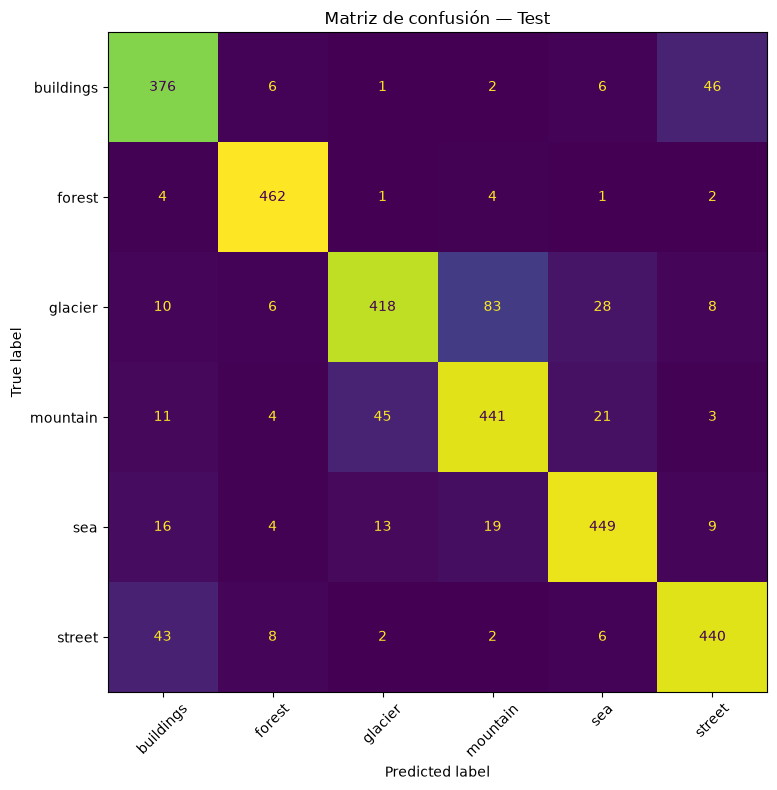

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)

plt.title("Matriz de confusión — Test")
plt.tight_layout()
plt.show()

### Identificar las confusiones principales



In [67]:
confusions = []

for real_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):
        if real_idx != pred_idx:
            count = cm[real_idx, pred_idx]
            if count > 0:
                confusions.append(
                    (
                        count,
                        real_idx,
                        pred_idx
                    )
                )

confusions.sort(reverse=True, key=lambda x: x[0])

print("Principales confusiones:")

for count, real_idx, pred_idx in confusions[:10]:
    print(
        f"{class_names[real_idx]:10s}"
        f" → "
        f"{class_names[pred_idx]:10s}"
        f": {count}"
    )

Principales confusiones:
glacier    → mountain  : 83
buildings  → street    : 46
mountain   → glacier   : 45
street     → buildings : 43
glacier    → sea       : 28
mountain   → sea       : 21
sea        → mountain  : 19
sea        → buildings : 16
sea        → glacier   : 13
mountain   → buildings : 11


### Interpretación de las confusiones

La confusión dominante es `glacier → mountain` con 83 casos, seguida de `buildings → street` con 46 y `mountain → glacier` con 45. Las parejas urbanas también comparten texturas y estructuras puede ser solapamiento visual entre clases, no como un problema de desbalance

## Análisis visual de errores, conclusiones y limitaciones

In [69]:
visual_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor()
])

In [ ]:
test_visual_dataset = datasets.ImageFolder(TEST_DIR, transform=visual_transform)

In [71]:
assert (
    test_visual_dataset.samples
    == test_dataset.samples
), "Los datasets de test no tienen el mismo orden."

### Localizar todos los errores



In [73]:
incorrect_indices = np.where(y_true != y_pred)[0]

print(
    "Predicciones incorrectas:",
    len(incorrect_indices)
)

print(
    "Predicciones correctas:",
    (y_true == y_pred).sum()
)

Predicciones incorrectas: 414
Predicciones correctas: 2586


### Visualizar una muestra reproducible de errores

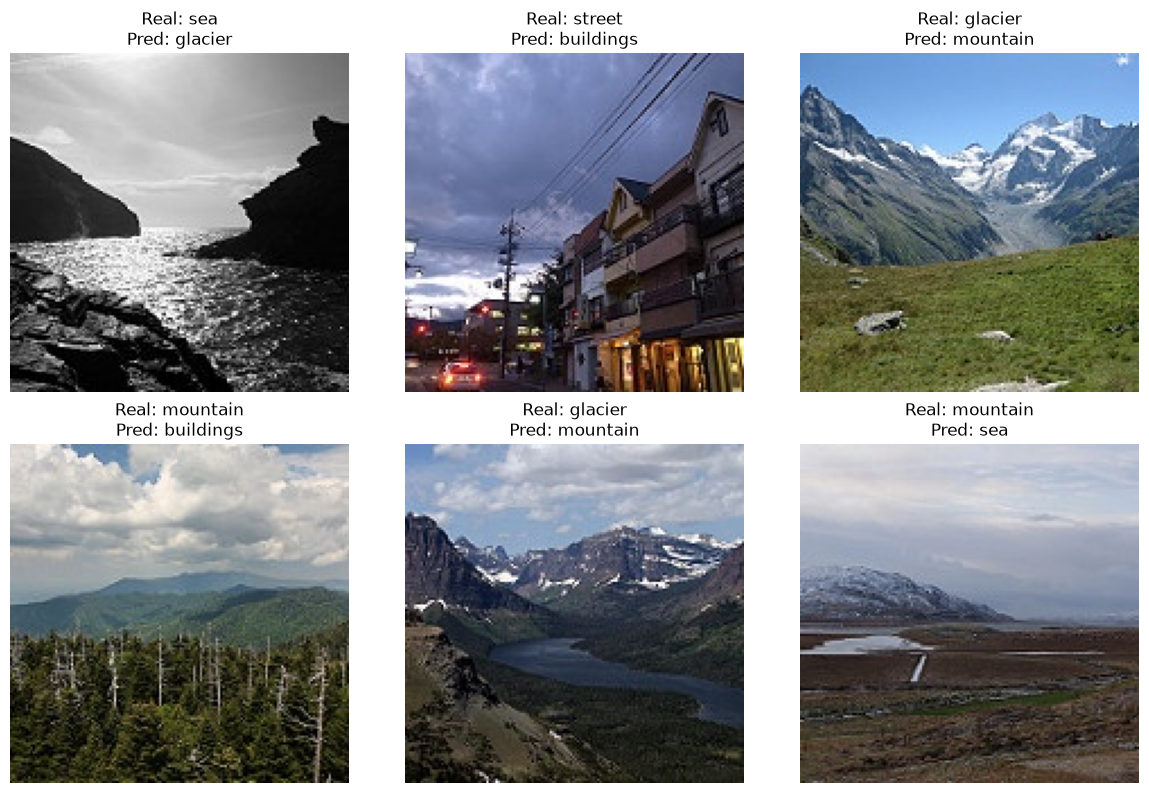

In [ ]:
rng = np.random.default_rng(SEED)

num_examples = min(6, len(incorrect_indices))

if num_examples > 0:
    selected_errors = rng.choice(incorrect_indices, size=num_examples, replace=False)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    for ax in axes.flat:
        ax.axis("off")

    for ax, idx in zip(axes.flat, selected_errors):
        image, _ = (test_visual_dataset[idx])
        ax.imshow(image.permute(1, 2, 0))

        ax.set_title(
            f"Real: "
            f"{class_names[y_true[idx]]}\n"
            f"Pred: "
            f"{class_names[y_pred[idx]]}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No existen errores para visualizar.")

### Analizar visualmente la confusión dominante

Analizando: glacier → mountain
Número de ejemplos: 83


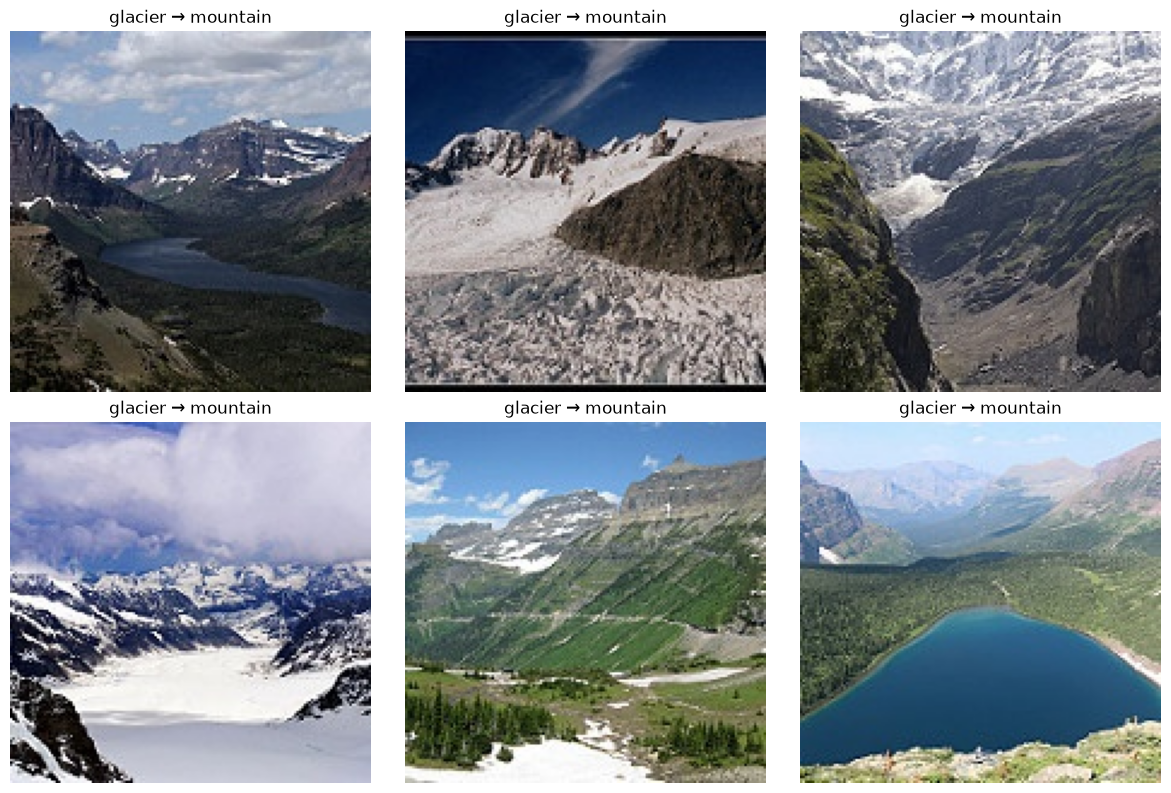

In [ ]:
if confusions:

    top_count, top_real, top_pred = (confusions[0])
    specific_errors = np.where((y_true == top_real) & (y_pred == top_pred))[0]

    print(
        "Analizando:",
        class_names[top_real],
        "→",
        class_names[top_pred]
    )

    print(
        "Número de ejemplos:",
        len(specific_errors)
    )

    num_specific = min(6, len(specific_errors))
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    for ax in axes.flat:
        ax.axis("off")

    for ax, idx in zip(axes.flat, specific_errors[:num_specific]):
        image, _ = (test_visual_dataset[idx])
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(
            f"{class_names[top_real]}"
            f" → "
            f"{class_names[top_pred]}"
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()

`glacier → mountain` es la confusión más frecuente, con 83 ejemplos, y ambas escenas pueden compartir nieve, cielo y relieve, mi hipotésis es que la confusión se debe a que ambas clases contienen nieve y cielo, y la red no ha aprendido a distinguir la forma de las montañas de los glaciares. Sin embargo, la matriz también muestra confusiones importantes entre `buildings` y `street`, por lo que el límite del modelo parece estar relacionado con el solapamiento visual entre varias categorías

### Registrar el resultado final del experimento

In [77]:
experiment_summary = {
    "dataset": "Intel Image Classification",
    "classes": class_names,
    "image_size": IMAGE_SIZE,
    "train_images": len(train_dataset),
    "validation_images": len(val_dataset),
    "test_images": len(test_dataset),
    "mean": MEAN,
    "std": STD,
    "architecture": "SceneCNN",
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "seed": SEED,
    "best_epoch": best_epoch,
    "best_validation_loss": best_val_loss,
    "test_accuracy": test_accuracy,
    "best_f1_class": best_f1_class,
    "worst_f1_class": worst_f1_class,
    "device": str(device)
}

for key, value in experiment_summary.items():

    print(
        f"{key:22s}: {value}"
    )

dataset               : Intel Image Classification
classes               : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
image_size            : 150
train_images          : 11227
validation_images     : 2807
test_images           : 3000
mean                  : [0.43040627241134644, 0.4574933350086212, 0.4535215198993683]
std                   : [0.2693118751049042, 0.2678605616092682, 0.2985861897468567]
architecture          : SceneCNN
optimizer             : Adam
learning_rate         : 0.001
batch_size            : 32
epochs                : 15
seed                  : 99
best_epoch            : 12
best_validation_loss  : 0.3841418308170402
test_accuracy         : 0.862
best_f1_class         : forest
worst_f1_class        : glacier
device                : mps


## Conclusiones del experimento

- Las imágenes se modificaron a 150 x 150, se normalizaron con estadísticas calculadas solo sobre entrenamiento y se mantiene `seg_test` aislado.

- La CNN alcanza 86,20% de accuracy en test, con un comportamiento similar al observado en validación.

- `forest` es la clase más sencilla para este modelo y `glacier` la más problemática; la confusión principal es `glacier → mountain`.

- La diferencia entre accuracy de entrenamiento y validación, junto con el empeoramiento de la pérdida de validación tras la época 12, apunta a sobreajuste.

- Como siguiente mejora, sería razonable comparar aumento de datos y transferencia de aprendizaje, especialmente para las clases visualmente solapadas.